# Teleportación cuántica con Qiskit

## 0. Instalación


In [1]:
!pip -q install qiskit qiskit-aer matplotlib pylatexenc



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 1. Importamos lo que vamos a usar

Qiskit, el simulador de Aer y algunas herramientas para medir

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    amplitude_damping_error,
    phase_damping_error,
    thermal_relaxation_error,
    ReadoutError,
)
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity
from qiskit.visualization import plot_histogram


## 2. Elegimos el estado que queremos teleportar

Vamos a crear un estado cualquiera de un qubit usando dos rotaciones: $$|\psi\rangle = R_z(\phi)R_y(\theta)|0\rangle$$


Estado objetivo |psi>:
[0.3893-0.1333j 0.8623+0.2952j]


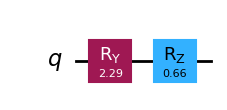

In [3]:
theta = 0.73 * np.pi # los ángulos son aleatorios Elena
phi = 0.21 * np.pi   # simplemente para probar con un estado no muy trivial
shots = 4096

# Circuito pequeñito solo para preparar el estado que queremos teleportar
prep = QuantumCircuit(1)
prep.ry(theta, 0)
prep.rz(phi, 0)

# Guardamos el estado objetivo para compararlo luego con el qubit de Bob
# (Bob es el que recibe)
target_state = Statevector.from_instruction(prep)
target_dm = DensityMatrix(target_state)

print("Estado objetivo |psi>:")
print(np.round(target_state.data, 4))
prep.draw("mpl")


## 3. El circuito de teleportación

Tenemos 3 qubits:

- `q0`: el qubit con el estado que Alice quiere mandar
- `q1`: la mitad de Alice del par entrelazado
- `q2`: el qubit de Bob

En la teleportación real, Alice mide y le manda dos bits clásicos a Bob. Bob usa esos bits para decidir si aplica una corrección `X`, una `Z`, ambas o ninguna.


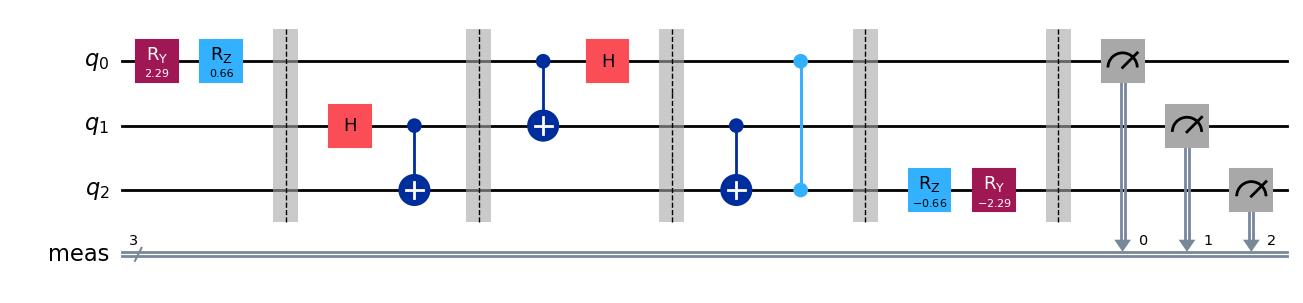

In [4]:
def teleportation_coherent_circuit(theta, phi, save_dm=True):
    """Circuito de teleportación sin medidas intermedias

    Es ideal para calcular la fidelidad usando matrices de densidad

    Solo lo utilizamos para eso, para comprobar :)
    """
    qc = QuantumCircuit(3, name="teleportacion_coherente")

    # 1) Alice prepara el estado que quiere mandar
    qc.ry(theta, 0)
    qc.rz(phi, 0)
    qc.barrier()

    # 2) Creamos un par de Bell (entrelazamiento) entre Alice q1 y Bob q2
    qc.h(1)
    qc.cx(1, 2)
    qc.barrier()

    # 3) Alice mezcla (entrelaza otra vez) su qubit original con su mitad del par de Bell
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    # 4) Correcciones de Bob, escritas como puertas controladas
    qc.cx(1, 2)  # si q1 fuera 1, Bob aplicaría X
    qc.cz(0, 2)  # si q0 fuera 1, Bob aplicaría Z

    # Guardamos la matriz de densidad final para poder analizar a Bob.
    if save_dm:
        qc.save_density_matrix()

    return qc


def teleportation_success_circuit(theta, phi):
    """Circuito para comprobar el éxito con mediciones

    Truco: si Bob tiene de verdad |psi>, deshacemos la preparación en q2
    con el circuito de preparación estado inverso y entonces Bob debería medir
    0 casi siempre ;)
    """
    qc = teleportation_coherent_circuit(theta, phi, save_dm=False)
    qc.barrier()

    # Deshacemos el estado de Bob: aplicamos U^dagger.
    qc.rz(-phi, 2)
    qc.ry(-theta, 2)

    qc.measure_all()
    return qc


qc_dm = teleportation_coherent_circuit(theta, phi)
qc_meas = teleportation_success_circuit(theta, phi)

qc_meas.draw("mpl")


## 4. Dos formas de comprobar si funcionó

Vamos a mirar dos cosas:

1. **Fidelidad**: número entre 0 y 1 que dice qué tan parecido es el qubit de Bob al estado original. Si vale 1, perfecto.
2. **Probabilidad de éxito en medición**: deshacemos la preparación en Bob y medimos. Si todo fue bien, Bob debería salir en `0`.

**Fíjate en el argumento noise_model, ahí es donde metemos luego el tipo y cantidad de ruido**


In [5]:
def bob_fidelity(noise_model=None, optimization_level=0):
    """Devuelve la fidelidad entre el estado de Bob y el estado objetivo."""
    backend = AerSimulator(method="density_matrix", noise_model=noise_model)
    tqc = transpile(qc_dm, backend, optimization_level=optimization_level)
    result = backend.run(tqc, shots=1).result()

    rho_3q = DensityMatrix(result.data(0)["density_matrix"])

    # Nos quedamos solo con el qubit de Bob, q2.
    # partial_trace descarta q0 y q1.
    rho_bob = partial_trace(rho_3q, [0, 1])

    return float(np.real(state_fidelity(rho_bob, target_dm)))


def bob_success_counts(noise_model=None, shots=4096, optimization_level=0):
    """Devuelve los conteos y la probabilidad de que Bob mida 0."""
    backend = AerSimulator(noise_model=noise_model)
    tqc = transpile(qc_meas, backend, optimization_level=optimization_level)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()

    # En las claves tipo '010', el bit de q2 aparece a la izquierda.
    p_bob_0 = sum(
        v for bitstring, v in counts.items()
        if bitstring.replace(" ", "")[0] == "0"
    ) / shots

    return counts, p_bob_0


## 5. Ahora sí: metemos ruido

Un `NoiseModel` le dice al simulador: "cada vez que aparezca tal puerta, ponle este error"

Vamos a probar varios ruidos típicos:

- **Despolarizante**: como si el qubit se volviera un poco aleatorio
- **Amortiguamiento de amplitud**: simula que el qubit tiende a relajarse hacia $|0\rangle$. Los qubits reales tienen este problema
- **Amortiguamiento de fase**: se deteriora solo la fase
- **Relajación térmica $T_1/T_2$**: una versión más física de decoherencia (pasa de este de momento, que es más complicado, pero la idea es que cuanto más tiempo dure la cosa, más se fastidia todo)
- **Error de lectura**: el qubit está bien, pero el aparato lo lee mal

Las tasas están puestas bastante visibles para que se note en las gráficas


In [6]:
one_qubit_gates = ["h", "x", "sx", "rx", "ry", "rz"]
two_qubit_gates = ["cx", "cz"]


def depolarizing_noise(p1=0.003, p2=0.03):
    #p1 (probabilidad de error en puertas de 1 q), p2 (probabilidad de error en puertas de 2q)
    """Ruido que mezcla el estado con algo aleatorio"""
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(p1, 1), one_qubit_gates)
    nm.add_all_qubit_quantum_error(depolarizing_error(p2, 2), two_qubit_gates)
    return nm


def amplitude_damping_noise(gamma=0.02):
    #gamma es la probabilidad de que el qubit caiga de 1 a 0
    """Ruido tipo relajación: el qubit tiende a caer hacia |0>"""
    nm = NoiseModel()
    e1 = amplitude_damping_error(gamma)
    e2 = e1.tensor(e1)
    nm.add_all_qubit_quantum_error(e1, one_qubit_gates)
    nm.add_all_qubit_quantum_error(e2, two_qubit_gates)
    return nm


def phase_damping_noise(lam=0.03):
    #lam es la probabilidad de perder la coherencia de fase
    """Ruido que borra fase: fastidia superposiciones sin cambiar tanto poblaciones"""
    nm = NoiseModel()
    e1 = phase_damping_error(lam)
    e2 = e1.tensor(e1)
    nm.add_all_qubit_quantum_error(e1, one_qubit_gates)
    nm.add_all_qubit_quantum_error(e2, two_qubit_gates)
    return nm


def thermal_relaxation_noise(t1=50e3, t2=70e3, gate_time_1q=50, gate_time_2q=300):
    #t1 tiempo de relajación energética 1->0
    #t2 tiempo de decoherencia (fase)
    #gate_time_1q duración de puertas de 1q
    #gate_time_2q duración de puertas de 2q
    """Ruido más físico basado en T1 y T2

    Importante: las unidades deben ser consistentes.
    Aquí usamos ns para T1/T2 y para tiempos de puerta.
    Además, Qiskit pide que T2 <= 2*T1.
    """
    nm = NoiseModel()
    e1 = thermal_relaxation_error(t1, t2, gate_time_1q)
    e2 = thermal_relaxation_error(t1, t2, gate_time_2q).tensor(
        thermal_relaxation_error(t1, t2, gate_time_2q)
    )
    nm.add_all_qubit_quantum_error(e1, one_qubit_gates)
    nm.add_all_qubit_quantum_error(e2, two_qubit_gates)
    return nm


def readout_noise(p01=0.03, p10=0.06):
    """Error de lectura.
    p01: el qubit era 0, pero lo leemos como 1.
    p10: el qubit era 1, pero lo leemos como 0.
    """
    nm = NoiseModel()
    ro = ReadoutError([[1 - p01, p01], [p10, 1 - p10]])
    nm.add_all_qubit_readout_error(ro)
    return nm


noise_models = {
    "ideal / sin ruido": None,
    "despolarizante": depolarizing_noise(p1=0.002, p2=0.01),
    #"despolarizante Qmio": depolarizing_noise(p1=0.02, p2=0.05),
    "amortiguamiento de amplitud": amplitude_damping_noise(gamma=0.01),
    #"amortiguamiento de amplitud Qimio": amplitude_damping_noise(gamma=0.15),
    "amortiguamiento de fase": phase_damping_noise(lam=0.01),
    #"amortiguamiento de fase Qmio": phase_damping_noise(lam=0.05),
    "relajación térmica T1/T2": thermal_relaxation_noise(
        t1=50e3,
        #t1=50e3,
        t2=50e3,
        #t2=50e3,
        gate_time_1q=50,
        #gate_time_1q=80,
        gate_time_2q=300,
        #gate_time_2q=600,
    ),
    "error de lectura": readout_noise(p01=0.02, p10=0.02),
    #"error de lectura": readout_noise(p01=0.08, p10=0.08),
}


## 6. Comparamos todos los casos

Un detalle: el error de lectura puede no bajar la fidelidad, porque la fidelidad se calcula antes de medir. Pero sí puede cambiar los resultados de los histogramas, porque ahí ya dependemos de cómo el aparato lee los bits.


In [7]:
rows = []
all_counts = {}

for name, nm in noise_models.items():
    fidelity = bob_fidelity(nm)
    counts, p_success = bob_success_counts(nm, shots=shots)

    rows.append((name, fidelity, p_success))
    all_counts[name] = counts

print(f"{'modelo':35s}  {'fidelidad Bob':>14s}  {'P(Bob=0 tras U-dagger)':>24s}")
print("-" * 82)

for name, fidelity, p_success in rows:
    print(f"{name:35s}  {fidelity:14.5f}  {p_success:24.5f}")


modelo                                fidelidad Bob    P(Bob=0 tras U-dagger)
----------------------------------------------------------------------------------
ideal / sin ruido                           1.00000                   1.00000
despolarizante                              0.97730                   0.96997
amortiguamiento de amplitud                 0.95751                   0.95679
amortiguamiento de fase                     0.98891                   0.98755
relajación térmica T1/T2                    0.97851                   0.97876
error de lectura                            1.00000                   0.97998


## 7. Gráficas para verlo de un vistazo

Cuanto más cerca de 1, mejor.


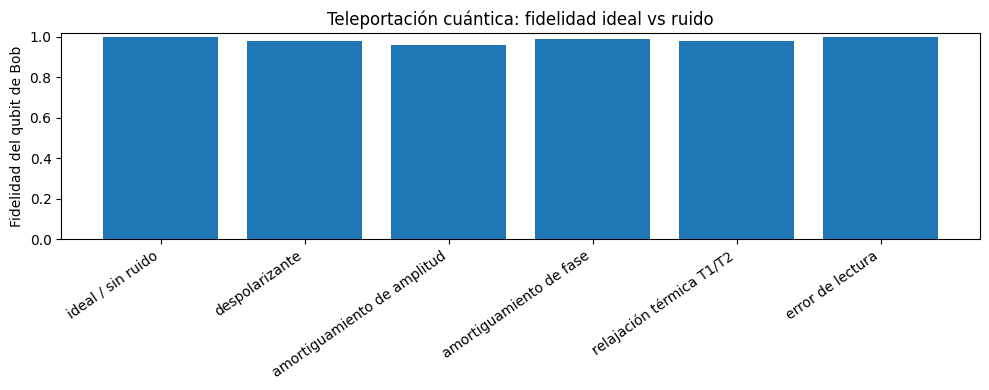

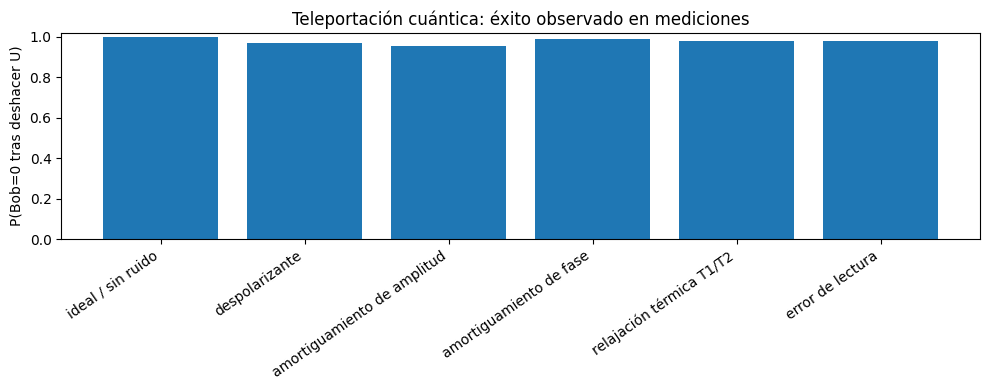

In [8]:
labels = [r[0] for r in rows]
fidelities = [r[1] for r in rows]
successes = [r[2] for r in rows]

plt.figure(figsize=(10, 4))
plt.bar(labels, fidelities)
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.02)
plt.ylabel("Fidelidad del qubit de Bob")
plt.title("Teleportación cuántica: fidelidad ideal vs ruido")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(labels, successes)
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.02)
plt.ylabel("P(Bob=0 tras deshacer U)")
plt.title("Teleportación cuántica: éxito observado en mediciones")
plt.tight_layout()
plt.show()


## 8. Histogramas

Lo que nos importa para Bob es el bit de `q2`, que aparece a la izquierda.


In [9]:
for name in [
    "ideal / sin ruido",
    "despolarizante",
    "amortiguamiento de amplitud",
    "amortiguamiento de fase",
    "relajación térmica T1/T2",
    "error de lectura",
]:
    print(name)
    print(all_counts[name])
    plot_histogram(all_counts[name], title=name)
    plt.show()


ideal / sin ruido
{'011': 1029, '001': 1063, '010': 999, '000': 1005}
despolarizante
{'101': 29, '100': 28, '110': 37, '111': 29, '011': 967, '001': 990, '010': 1005, '000': 1011}
amortiguamiento de amplitud
{'110': 41, '101': 44, '100': 56, '111': 36, '011': 948, '000': 998, '010': 1000, '001': 973}
amortiguamiento de fase
{'110': 8, '100': 21, '101': 15, '111': 7, '011': 1006, '010': 1071, '000': 959, '001': 1009}
relajación térmica T1/T2
{'100': 26, '101': 24, '001': 951, '110': 15, '010': 973, '000': 1063, '111': 22, '011': 1022}
error de lectura
{'101': 17, '110': 26, '100': 23, '000': 1018, '010': 1013, '111': 16, '011': 990, '001': 993}


## 9. Barrido

Lo chulo es estudiar la evolución del ruido. Así vemos cómo se va cayendo la fidelidad cuando el ruido se vuelve más fuerte.


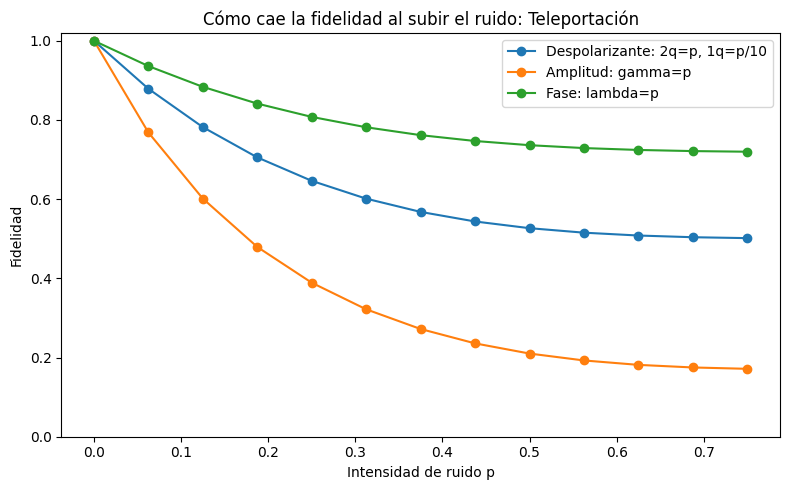

In [10]:
ps = np.linspace(0, 0.75, 13)

scan_dep = []
scan_amp = []
scan_phase = []

for p in ps:
    scan_dep.append(bob_fidelity(depolarizing_noise(p1=p / 10, p2=p)))
    scan_amp.append(bob_fidelity(amplitude_damping_noise(gamma=p)))
    scan_phase.append(bob_fidelity(phase_damping_noise(lam=p)))

plt.figure(figsize=(8, 5))
plt.plot(ps, scan_dep, marker="o", label="Despolarizante: 2q=p, 1q=p/10")
plt.plot(ps, scan_amp, marker="o", label="Amplitud: gamma=p")
plt.plot(ps, scan_phase, marker="o", label="Fase: lambda=p")
plt.xlabel("Intensidad de ruido p")
plt.ylabel("Fidelidad")
plt.ylim(0, 1.02)
plt.title("Cómo cae la fidelidad al subir el ruido: Teleportación")
plt.legend()
plt.tight_layout()
plt.show()


## 10. Mini plantilla para aplicar ruido


```python
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.01, 1), ["h", "x", "sx"])
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05, 2), ["cx"])

backend = AerSimulator(noise_model=noise_model)
tqc = transpile(circuito, backend)
result = backend.run(tqc, shots=4096).result()
```
